# S03: Maximum Common Substructure in Reaction Informatics

This talktorial introduces maximum common substructure (MCS) as a practical molecular-alignment tool for reaction informatics. We compare chemistry-aware RDKit MCS with explicit graph-level reasoning, then use the same idea for reaction rebalancing [\[1\]](#6.-References), [\[2\]](#6.-References), [\[3\]](#6.-References).


## Aim of this talktorial

1. Use **MCS-based molecular alignment** to compare molecules that differ by edits, substitutions, or missing components.
2. Interpret where RDKit MCS and graph-based MCS agree or differ.
3. Apply MCS reasoning to simple **reaction rebalancing** examples and connect it to SynRBL.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- define **maximum common substructure** as a shared labeled subgraph,
- compute and interpret MCS results with **RDKit**,
- convert an MCS into an atom-level alignment between molecules,
- explain why MCS results may be non-unique or sensitive to matching constraints,
- use MCS-based alignment to reason about partial or noisy reactions, and
- apply MCS ideas to simple **reaction rebalancing** examples.

---

## Outline

- [0. Setup & Data](#0.-Setup-&-Data)
- [1. Maximum Common Substructure](#1.-Maximum-Common-Substructure)
- [2. Rule-based reaction rebalancing](#2.-Rule-based-reaction-rebalancing)
- [3. MCS-based reaction rebalancing](#3.-MCS-based-reaction-rebalancing)
- [4. Discussion](#4.-Discussion)
- [5. Quiz](#5.-Quiz)
- [6. References](#6.-References)

## 0. Setup & Data

In [1]:
import rdkit
from rdkit import Chem
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from synedu.Utils.vis import draw_molecular_graph  # for visualization

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "molecules.csv"
df = pd.read_csv(CSV_PATH)
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
display(df)

RDKit version: 2025.09.3
NetworkX version: 3.6.1


,smiles,name,mol
0,CCO,ethanol,<rdkit.Chem.rdchem.Mol object at 0x7fbdc85f15b0>
1,CCCl,chloroethane,<rdkit.Chem.rdchem.Mol object at 0x7fbdc85f1690>
2,CCOCC,diethyl ether,<rdkit.Chem.rdchem.Mol object at 0x7fbdc85f1700>
3,O,water,<rdkit.Chem.rdchem.Mol object at 0x7fbdc85f1770>
4,NCC(=O)O,glycine,<rdkit.Chem.rdchem.Mol object at 0x7fbdc85f17e0>
...,...,...,...
995,CNCC(O)c1ccc(O)cc1,oxedrine,<rdkit.Chem.rdchem.Mol object at 0x7fbdc786cd60>
996,Cc1nc(Nc2ccc(F)cc2)nc(N2CCc3ccccc3C2C)c1C,revaprazan,<rdkit.Chem.rdchem.Mol object at 0x7fbdc786cdd0>
997,O=C(O)CCC(=O)c1ccc2c(c1)-c1cccc3cccc-2c13,florantyrone,<rdkit.Chem.rdchem.Mol object at 0x7fbdc786ce40>
998,COC(=O)CCC[N+](C)(C)C,carpronium,<rdkit.Chem.rdchem.Mol object at 0x7fbdc786ceb0>


## 1. Maximum Common Substructure

The **Maximum Common Substructure (MCS)** [\[2\]](#6.-References), [\[4\]](#6.-References) problem seeks the largest subgraph
shared by two molecular graphs. It serves as a core **alignment primitive** for
molecular similarity, substructure transfer, and as a common starting point for
**atom mapping**.

---

### 1.1 Theory

Let
$$
G = \bigl( V_G, E_G, a_G, b_G \bigr), \qquad
H = \bigl( V_H, E_H, a_H, b_H \bigr)
$$
be **labeled molecular graphs**, where
$$
a(\cdot) \text{ denotes atom labels}, \qquad
b(\cdot) \text{ denotes bond labels}.
$$

A graph
$$
S = (V_S, E_S, a_S, b_S)
$$
is a **common subgraph** of \(G\) and \(H\) if there exist **injective graph
morphisms**
$$
f : S \hookrightarrow G, \qquad
g : S \hookrightarrow H,
$$
that preserve adjacency and all labels.

An **MCS** is a common subgraph
$$
S^\star
$$
that maximizes the number of vertices, i.e.
$$
|V(S^\star)| \;\ge\; |V(S)| \qquad
\forall\, S \text{ such that } S \subseteq G \text{ and } S \subseteq H .
$$

**Practical notes.**
- MCSs are generally **not unique**.
- Imposing chemical constraints (atom and bond types, aromaticity, ring
  membership, chirality) restricts the admissible morphisms and can change the
  resulting MCS.

**Definition (Maximum Common Substructure / MCS).**  
Given two labeled graphs $G_1$ and $G_2$, a *common subgraph* is a graph $C$ together with label-preserving injective morphisms $\iota_1: C \hookrightarrow G_1$ and $\iota_2: C \hookrightarrow G_2$.  
The *maximum common subgraph* (MCS) is a common subgraph $C^*$ of maximum cardinality $|V(C^*)|$ (maximum common substructure by atoms) or maximum $|E(C^*)|$ (by bonds).

**Remark.** MCS computation is NP-hard in general [\[4\]](#6.-References). RDKit uses an FMCS heuristic that may return a *locally* maximal but not globally maximal common subgraph. NetworkX-based MCS uses exact backtracking, which is exponential in the worst case but exact.

**Definition (Normalized MCS size).**  
Given an MCS $C^*$ of two molecules, the *normalized MCS size* (Tanimoto-like) is:

$$
\tau_{\text{MCS}}(G_1, G_2) = \frac{|V(C^*)|}{|V(G_1)| + |V(G_2)| - |V(C^*)|}
$$

This is 1 if the molecules are isomorphic and 0 if they share no atom.

### 1.2. RDkit MCS

In **RDKit**, the **maximum common substructure (MCS)** can be computed using
`rdkit.Chem.rdFMCS` [\[5\]](#6.-References). 

RDKit MCS is commonly used for molecular alignment, reaction analysis, and as a
basis for atom mapping.

MCS SMARTS: [#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Mol 1: 7 atoms, MCS matches: 1
Mol 2: 7 atoms, MCS matches: 1

Atom mapping (mol1_atom -> mol2_atom) for first embeddings:
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6)]


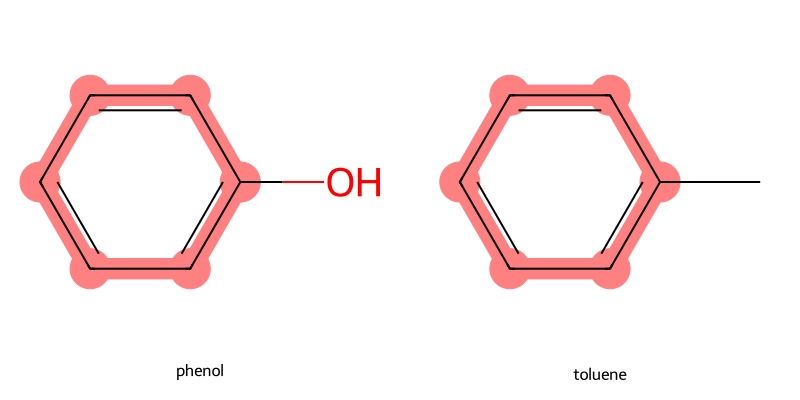

In [2]:
from rdkit import Chem
from rdkit.Chem import rdFMCS, Draw


def rdkit_mcs(
    mols,
    timeout: int = 10,
    ringMatchesRingOnly: bool = True,
    atomCompare=rdFMCS.AtomCompare.CompareElements,
    bondCompare=rdFMCS.BondCompare.CompareOrder,
):
    """
    Return the MCS SMARTS string and the rdFMCS result object.
    `mols` can be a list of RDKit Mol objects or SMILES strings.
    """
    mol_objs = [Chem.MolFromSmiles(s) if isinstance(s, str) else s for s in mols]
    res = rdFMCS.FindMCS(
        mol_objs,
        atomCompare=atomCompare,
        bondCompare=bondCompare,
        ringMatchesRingOnly=ringMatchesRingOnly,
        timeout=timeout,
    )
    return res.smartsString, res


def show_mcs_and_highlight(
    mols, smarts=None, show_all_matches=False, subimg_size=(300, 300)
):
    """
    Compute (or accept) MCS SMARTS, enumerate matches in each molecule,
    print a first-match atom-index mapping, and draw the molecules with
    highlighted MCS atoms.
    """
    # Accept SMILES or Mol
    mol_objs = [Chem.MolFromSmiles(s) if isinstance(s, str) else s for s in mols]
    if smarts is None:
        smarts, _ = rdkit_mcs(mol_objs)
    mcs_query = Chem.MolFromSmarts(smarts)

    # find matches
    matches = [tuple(m.GetSubstructMatches(mcs_query)) for m in mol_objs]
    match_counts = [len(ms) for ms in matches]

    print("MCS SMARTS:", smarts)
    for i, (m, cnt) in enumerate(zip(mol_objs, match_counts)):
        print(f"Mol {i+1}: {m.GetNumAtoms()} atoms, MCS matches: {cnt}")

    # If no matches found (shouldn't happen), return
    if any(cnt == 0 for cnt in match_counts):
        print("Warning: no MCS embedding found in one or more molecules.")
        return

    # Show mapping for the *first* embedding in each molecule
    first_matches = [ms[0] for ms in matches]
    mapping = (
        list(zip(first_matches[0], first_matches[1]))
        if len(first_matches) >= 2
        else None
    )
    if mapping:
        print("\nAtom mapping (mol1_atom -> mol2_atom) for first embeddings:")
        print(mapping)

    # Prepare highlight lists: choose which embedding to highlight for each molecule
    if show_all_matches:
        # create list-of-lists where we highlight all embeddings (flatten duplicates visually)
        hl_lists = [list(set(sum([list(t) for t in ms], []))) for ms in matches]
    else:
        hl_lists = [list(ms[0]) for ms in matches]

    # Legend labels
    legends = [
        mol.GetProp("_Name") if mol.HasProp("_Name") else f"Mol {i+1}"
        for i, mol in enumerate(mol_objs)
    ]

    # Draw side-by-side with highlighted atoms
    img = Draw.MolsToGridImage(
        mol_objs,
        molsPerRow=len(mol_objs),
        subImgSize=subimg_size,
        legends=legends,
        highlightAtomLists=hl_lists,
    )
    display(img)  # in a Jupyter notebook; returns PIL Image otherwise


m1 = Chem.MolFromSmiles("Oc1ccccc1")
m1.SetProp("_Name", "phenol")
m2 = Chem.MolFromSmiles("Cc1ccccc1")
m2.SetProp("_Name", "toluene")

smarts, res = rdkit_mcs([m1, m2])
show_mcs_and_highlight(
    [m1, m2], smarts=smarts, show_all_matches=False, subimg_size=(400, 400)
)

**Stored in `synedu.Utils`** — the MCS helpers are deposited for later reaction-alignment tasks:
```python
from synedu.Utils.mcs import rdkit_mcs, nx_mcs, mcs_size, mcs_class, map_edges
```
Later notebooks can reuse these functions without carrying the teaching implementation forward.

**Q1 — Compute the MCS between ethanol and another molecule**

Use **RDKit MCS** to compute the maximum common substructure between **ethanol**
and each molecule in the table, and record the **size of the MCS**.

This exercise shows how RDKit abstracts chemical similarity beyond strict
subgraph containment.

---

**Step-by-step tasks**

1. **Select ethanol as the reference molecule**  
   Use the RDKit molecule corresponding to ethanol (row 0).

2. **Compute RDKit MCS**  
   For each molecule, compute the MCS SMARTS between ethanol and the molecule
   using `rdkit_mcs`.

3. **Convert SMARTS to a molecule**  
   Turn the SMARTS into an RDKit query molecule.

4. **Measure MCS size**  
   Record the number of atoms in the MCS (or `0` if no MCS is found).

5. **Store the result**  
   Add a column `mcs_size_ethanol_rdkit`.

<details class="synedu-solution">
<summary><strong>Solution</strong></summary>

```python
ethanol_mol = df.loc[0, "mol"]

def rdkit_mcs_size_with_ethanol(mol):
    smarts, _ = rdkit_mcs([ethanol_mol, mol])
    if not smarts:
        return 0
    mcs_mol = Chem.MolFromSmarts(smarts)
    if mcs_mol is None:
        return 0
    return mcs_mol.GetNumAtoms()

df["mcs_size_ethanol_rdkit"] = df["mol"].apply(rdkit_mcs_size_with_ethanol)
df
```

</details>


### 1.3. NetworkX MCS

In [3]:
from __future__ import annotations

from itertools import combinations
from typing import Dict, Set, Tuple

import networkx as nx
from networkx.algorithms import isomorphism as iso
from rdkit import Chem


def nx_mcs(
    G: nx.Graph,
    H: nx.Graph,
    *,
    node_match,
    edge_match,
) -> tuple[nx.Graph, Dict[int, int]]:
    """
    Return one maximum common induced subgraph SG of G, plus a node mapping SG->H.
    Exponential; for teaching only.
    """
    nodes = list(G.nodes())
    for k in range(len(nodes), 0, -1):
        for subset in combinations(nodes, k):
            SG = G.subgraph(subset).copy()

            GM = iso.GraphMatcher(H, SG, node_match=node_match, edge_match=edge_match)
            if GM.subgraph_is_isomorphic():
                # GraphMatcher mapping is H -> SG; invert to get SG -> H
                h_to_sg = next(GM.subgraph_isomorphisms_iter())
                sg_to_h = {sg: h for h, sg in h_to_sg.items()}
                return SG, sg_to_h

    return nx.Graph(), {}


def _map_edges(
    SG: nx.Graph, sg_to_h: Dict[int, int], H: nx.Graph
) -> Set[Tuple[int, int]]:
    """Map SG edges into H using sg_to_h; returns undirected edge tuples."""
    out: Set[Tuple[int, int]] = set()
    for u, v in SG.edges():
        hu, hv = sg_to_h[u], sg_to_h[v]
        if H.has_edge(hu, hv):
            out.add((hu, hv))
    return out

MCS nodes: 6 MCS edges: 6
One SG->H mapping (first): {2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}


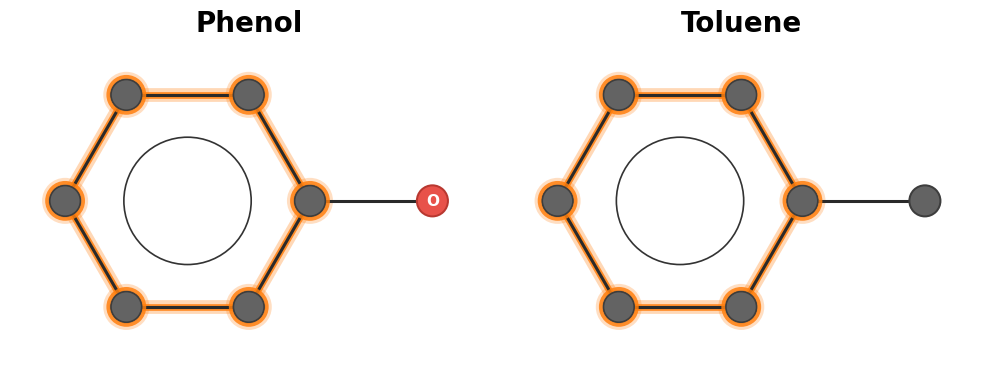

In [4]:
from synedu.Utils import mol_to_graph, node_match, edge_match, draw_molecular_graph
import matplotlib.pyplot as plt


m1 = Chem.MolFromSmiles("Oc1ccccc1")  # phenol
m2 = Chem.MolFromSmiles("Cc1ccccc1")  # toluene

# Convert to labeled NetworkX graphs (nodes must be atom indices)
m1_g = mol_to_graph(m1)
m2_g = mol_to_graph(m2)

# Compute NX MCS + one embedding (SG -> m2_g mapping)
SG, sg_to_h = nx_mcs(m1_g, m2_g, node_match=node_match, edge_match=edge_match)

print("MCS nodes:", SG.number_of_nodes(), "MCS edges:", SG.number_of_edges())
print("One SG->H mapping (first):", sg_to_h)

# Highlight sets
hl_m1_nodes = set(SG.nodes())
hl_m1_edges = set(SG.edges())

hl_m2_nodes = {sg_to_h[n] for n in SG.nodes()}
hl_m2_edges = _map_edges(SG, sg_to_h, m2_g)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

draw_molecular_graph(
    m1_g,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=hl_m1_nodes,
    highlight_edges=hl_m1_edges,
)
axes[0].set_title("Phenol", fontsize=20, weight='bold')

draw_molecular_graph(
    m2_g,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=hl_m2_nodes,
    highlight_edges=hl_m2_edges,
)
axes[1].set_title("Toluene", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

### MCS alignment gallery

Each row shows a molecule pair. The **highlighted (orange) atoms and bonds** form the maximum common substructure. Larger MCS → more shared scaffold; smaller MCS → structurally divergent molecules despite similar element composition.

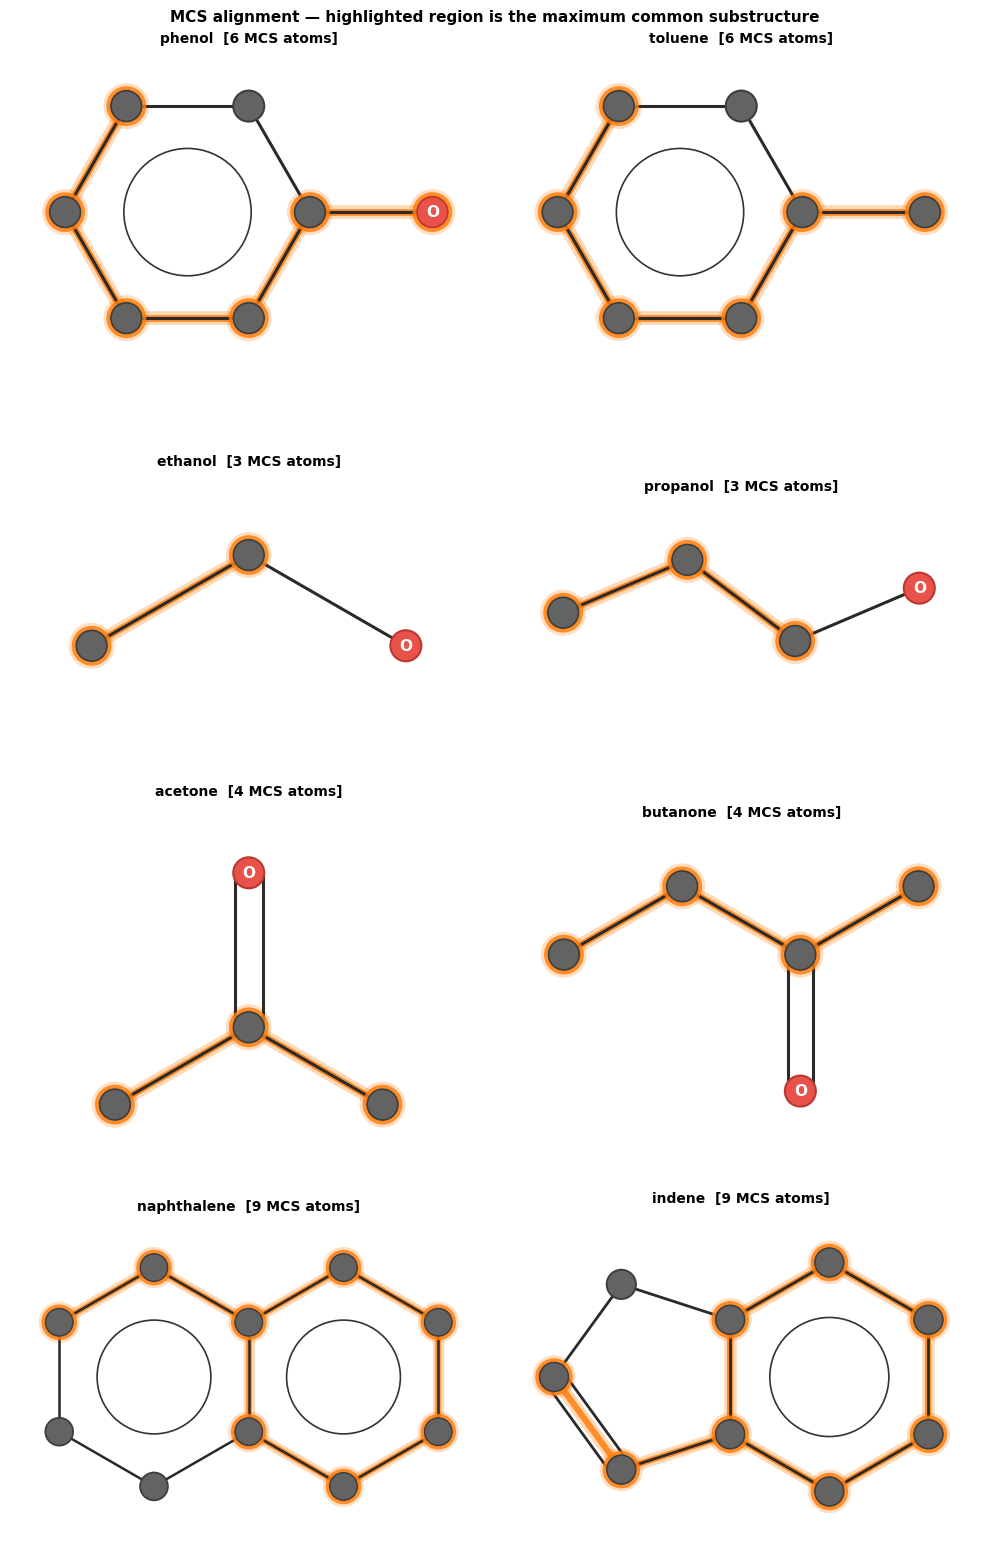

In [5]:
from rdkit import Chem
from rdkit.Chem import rdFMCS
import matplotlib.pyplot as plt
from synedu.Utils import mol_to_graph, draw_molecular_graph

_MCS_PAIRS = [
    ("phenol", "Oc1ccccc1", "toluene", "Cc1ccccc1"),
    ("ethanol", "CCO", "propanol", "CCCO"),
    ("acetone", "CC(C)=O", "butanone", "CCC(C)=O"),
    ("naphthalene", "c1ccc2ccccc2c1", "indene", "C1=CC2=CC=CC=C2C1"),
]

fig, axes = plt.subplots(len(_MCS_PAIRS), 2, figsize=(10, 4 * len(_MCS_PAIRS)))
fig.suptitle(
    "MCS alignment — highlighted region is the maximum common substructure",
    fontsize=11,
    fontweight="bold",
)

for row, (n1, smi1, n2, smi2) in enumerate(_MCS_PAIRS):
    m1 = Chem.MolFromSmiles(smi1)
    m2 = Chem.MolFromSmiles(smi2)
    g1 = mol_to_graph(m1)
    g2 = mol_to_graph(m2)

    smarts, _ = rdkit_mcs([m1, m2])
    mcs_q = Chem.MolFromSmarts(smarts) if smarts else None

    match1 = m1.GetSubstructMatch(mcs_q) if mcs_q else ()
    match2 = m2.GetSubstructMatch(mcs_q) if mcs_q else ()

    hl1 = set(match1)
    hl1_e = {(u, v) for u, v in g1.edges() if u in hl1 and v in hl1}
    hl2 = set(match2)
    hl2_e = {(u, v) for u, v in g2.edges() if u in hl2 and v in hl2}

    ax1, ax2 = axes[row, 0], axes[row, 1]
    draw_molecular_graph(
        g1,
        ax=ax1,
        include_mol=False,
        highlight_nodes=hl1,
        highlight_edges=hl1_e,
        highlight_color="#FF7F0E",
    )
    ax1.set_title(f"{n1}  [{len(hl1)} MCS atoms]", fontsize=10, weight="bold")

    draw_molecular_graph(
        g2,
        ax=ax2,
        include_mol=False,
        highlight_nodes=hl2,
        highlight_edges=hl2_e,
        highlight_color="#FF7F0E",
    )
    ax2.set_title(f"{n2}  [{len(hl2)} MCS atoms]", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()

**Q2 — Compute the MCS between ethanol and another molecule**

Compute the **MCS** between **ethanol** and each
molecule in the table using the **NetworkX-based MCS implementation**, and
record the size of the resulting common subgraph.

This exercise emphasizes a **strict graph-theoretic view** of MCS, in contrast
to the chemistry-aware RDKit approach in Q4.

---

**Step-by-step tasks**

1. **Select ethanol as the reference graph**  
   Use the NetworkX graph corresponding to ethanol (row 0).

2. **Compute NetworkX MCS**  
   For each molecule graph, compute an MCS using `nx_mcs`.

3. **Measure MCS size**  
   Record the number of nodes (atoms) in the resulting MCS graph.

4. **Store the result**  
   Add a new column `mcs_size_ethanol_nx` to the dataframe.

<details class="synedu-solution">
<summary><strong>Solution</strong></summary>

```python
# Reference graph: ethanol
df['graph'] = df['mol'].apply(mol_to_graph)
ethanol_G = df.loc[0, "graph"]

def nx_mcs_size_with_ethanol(host_G):
    S, _ = nx_mcs(
        ethanol_G,
        host_G,
        node_match=node_match,
        edge_match=edge_match,
    )
    if S is None:
        return 0
    return S.number_of_nodes()

# Add NetworkX MCS size column
df["mcs_size_ethanol_nx"] = df["graph"].apply(nx_mcs_size_with_ethanol)
```

</details>


Now we inspect the difference between rdkit and networkx

```python
df[df['mcs_size_ethanol_rdkit'] != df['mcs_size_ethanol_nx']]
```

Most discrepancies originate from **ring systems**. RDKit MCS is *chemistry-first*, enforcing ring–chain consistency, whereas NetworkX MCS is *graph-first* and performs purely topological matching. With `RingMatchesRingOnly=True`, RDKit allows atom matches only when both the pattern and host atoms belong to rings, preventing acyclic–ring correspondences. Consequently, cyclic hydrocarbons yield zero MCS with ethanol under RDKit but non-zero matches under unconstrained graph matching.

### MCS size vs Tanimoto similarity

Tanimoto similarity (fingerprint-based) and MCS size (graph-based) both measure molecular overlap, but they are **not equivalent** [\[4\]](#6.-References). The scatter plot below samples molecules from the dataset and compares both metrics against ethanol. Ring-containing molecules can have high graph MCS under RDKit's chemistry-aware matcher yet low Tanimoto — or vice versa.

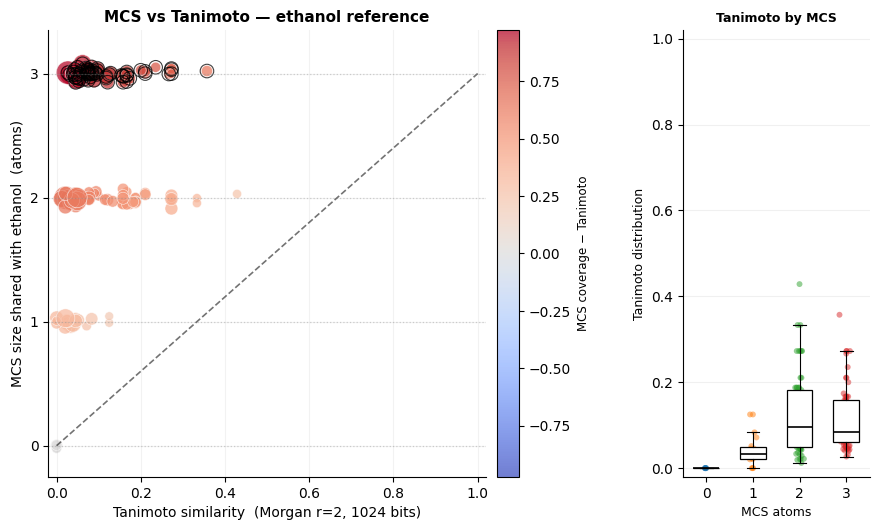

,canonical_smiles,tanimoto,mcs_atoms,mcs_ref_coverage,gap_mcs_minus_fp,heavy_atoms,class
0,N=C(N)NCCC[C@@H](N)C(=O)N[C@@H](CCCNC(=N)N)C(=...,0.027027,3,1.0,0.972973,92,full reference MCS
1,CO[C@@H]1[C@@H](O[C@@H]2O[C@H](C)[C@@H](O[C@H]...,0.031250,3,1.0,0.968750,62,full reference MCS
2,CC(=O)OCC(=O)[C@@]1(OC(=O)c2ccco2)[C@H](C)C[C@...,0.040000,3,1.0,0.960000,38,full reference MCS
3,CC(C)(O/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(C...,0.040541,3,1.0,0.959459,37,full reference MCS
4,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,0.043478,3,1.0,0.956522,27,full reference MCS
5,C[C@@H](O)[C@H](CO)NC(=O)[C@@H]1CSSC[C@H](NC(=...,0.044444,3,1.0,0.955556,71,full reference MCS
6,C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CC[C@@H](N)C...,0.044776,3,1.0,0.955224,35,full reference MCS
7,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,0.044776,3,1.0,0.955224,30,full reference MCS
8,OC(CCN1CCCCC1)(c1ccccc1)C1CC2C=CC1C2,0.045455,3,1.0,0.954545,23,full reference MCS
9,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H](CC...,0.050000,3,1.0,0.950000,33,full reference MCS


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFMCS
from rdkit.Chem import rdFingerprintGenerator

_ref_smi = "CCO"  # ethanol
_n_sample = 150
_random_state = 7
_mcs_timeout = 3

_fp_radius = 2
_fp_size = 1024


_ref_mol = Chem.MolFromSmiles(_ref_smi)
_ref_atoms = _ref_mol.GetNumAtoms()

_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=_fp_radius, fpSize=_fp_size
)

_ref_fp = _morgan_gen.GetFingerprint(_ref_mol)


def _safe_mol_from_smiles(smi):
    if not isinstance(smi, str) or not smi.strip():
        return None
    try:
        return Chem.MolFromSmiles(smi)
    except Exception:
        return None


def _mcs_size(mol_a, mol_b, timeout=3):
    """
    Return MCS atom count.

    This first tries your existing rdkit_mcs(...) wrapper if available.
    If not available, it falls back to RDKit's rdFMCS.FindMCS.
    """
    try:
        _smarts, _ = rdkit_mcs([mol_a, mol_b], timeout=timeout)
        _q = Chem.MolFromSmarts(_smarts) if _smarts else None
        return _q.GetNumAtoms() if _q is not None else 0

    except NameError:
        try:
            res = rdFMCS.FindMCS(
                [mol_a, mol_b],
                timeout=timeout,
                ringMatchesRingOnly=True,
                completeRingsOnly=True,
                matchValences=True,
            )
            if res.canceled or not res.smartsString:
                return 0
            _q = Chem.MolFromSmarts(res.smartsString)
            return _q.GetNumAtoms() if _q is not None else 0
        except Exception:
            return 0

    except Exception:
        return 0


def _mcs_class(mcs_atoms, ref_atoms):
    if mcs_atoms == ref_atoms:
        return "full reference MCS"
    elif mcs_atoms == ref_atoms - 1:
        return "large partial MCS"
    elif mcs_atoms == 1:
        return "single-atom MCS"
    else:
        return "weak/no MCS"


_sample_smis = (
    df["smiles"]
    .dropna()
    .drop_duplicates()
    .sample(
        n=min(_n_sample, df["smiles"].dropna().drop_duplicates().shape[0]),
        random_state=_random_state,
    )
    .tolist()
)

_records = []

for _smi in _sample_smis:
    _mol = _safe_mol_from_smiles(_smi)
    if _mol is None:
        continue

    _fp = _morgan_gen.GetFingerprint(_mol)
    _tan = DataStructs.TanimotoSimilarity(_ref_fp, _fp)

    _sz = _mcs_size(_ref_mol, _mol, timeout=_mcs_timeout)

    _mcs_cov = _sz / _ref_atoms
    _gap = _mcs_cov - _tan

    _records.append(
        {
            "smiles": _smi,
            "canonical_smiles": Chem.MolToSmiles(_mol),
            "tanimoto": _tan,
            "mcs_atoms": _sz,
            "mcs_ref_coverage": _mcs_cov,
            "gap_mcs_minus_fp": _gap,
            "heavy_atoms": _mol.GetNumHeavyAtoms(),
            "class": _mcs_class(_sz, _ref_atoms),
        }
    )

_pts = pd.DataFrame(_records)


if _pts.empty:
    print("No valid molecules found.")

else:
    rng = np.random.default_rng(_random_state)

    # Small vertical jitter reveals overlapping points while preserving integer MCS bands
    _pts["mcs_atoms_jitter"] = _pts["mcs_atoms"] + rng.normal(0, 0.035, size=len(_pts))

    fig = plt.figure(figsize=(10.6, 5.8))

    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[3.25, 1.15],
        wspace=0.30,
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_box = fig.add_subplot(gs[0, 1])

    _gap = _pts["gap_mcs_minus_fp"]
    _lim = max(abs(_gap.min()), abs(_gap.max()), 1e-6)

    _norm = mcolors.TwoSlopeNorm(
        vmin=-_lim,
        vcenter=0,
        vmax=_lim,
    )

    sc = ax.scatter(
        _pts["tanimoto"],
        _pts["mcs_atoms_jitter"],
        c=_pts["gap_mcs_minus_fp"],
        cmap="coolwarm",
        norm=_norm,
        s=35 + 2.7 * _pts["heavy_atoms"],
        alpha=0.72,
        edgecolors="white",
        linewidths=0.45,
    )

    _xline = np.linspace(0, 1, 200)

    ax.plot(
        _xline,
        _xline * _ref_atoms,
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.55,
    )

    # Integer MCS guide lines
    for y in range(_ref_atoms + 1):
        ax.axhline(
            y,
            linestyle=":",
            linewidth=0.9,
            color="gray",
            alpha=0.35,
        )

    # Highlight molecules with full ethanol-sized MCS
    full = _pts[_pts["mcs_atoms"] == _ref_atoms]

    ax.scatter(
        full["tanimoto"],
        full["mcs_atoms_jitter"],
        facecolors="none",
        edgecolors="black",
        s=95,
        linewidths=0.8,
        alpha=0.75,
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)

    cbar.set_label(
        "MCS coverage − Tanimoto",
        fontsize=8.5,
    )

    ax.set_xlabel(
        f"Tanimoto similarity  (Morgan r={_fp_radius}, {_fp_size} bits)",
        fontsize=10,
    )

    ax.set_ylabel(
        "MCS size shared with ethanol  (atoms)",
        fontsize=10,
    )

    ax.set_title(
        "MCS vs Tanimoto — ethanol reference",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.25, _ref_atoms + 0.35)
    ax.set_yticks(range(_ref_atoms + 1))

    ax.grid(alpha=0.16)
    ax.spines[["top", "right"]].set_visible(False)

    grouped = [
        _pts.loc[_pts["mcs_atoms"] == i, "tanimoto"].values
        for i in range(_ref_atoms + 1)
    ]

    ax_box.boxplot(
        grouped,
        positions=list(range(_ref_atoms + 1)),
        widths=0.55,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(
            facecolor="white",
            edgecolor="black",
            linewidth=0.9,
        ),
        medianprops=dict(
            color="black",
            linewidth=1.2,
        ),
        whiskerprops=dict(
            color="black",
            linewidth=0.8,
        ),
        capprops=dict(
            color="black",
            linewidth=0.8,
        ),
    )

    for i in range(_ref_atoms + 1):
        vals = _pts.loc[_pts["mcs_atoms"] == i, "tanimoto"].values
        if len(vals) == 0:
            continue

        xj = rng.normal(i, 0.045, size=len(vals))

        ax_box.scatter(
            xj,
            vals,
            s=18,
            alpha=0.5,
            edgecolors="none",
        )

    ax_box.set_xlabel("MCS atoms", fontsize=9)
    ax_box.set_ylabel("Tanimoto distribution", fontsize=9)

    ax_box.set_title(
        "Tanimoto by MCS",
        fontsize=9,
        fontweight="bold",
    )

    ax_box.set_xticks(range(_ref_atoms + 1))
    ax_box.set_ylim(-0.02, 1.02)

    ax_box.grid(axis="y", alpha=0.18)
    ax_box.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


if not _pts.empty:
    insight_table = _pts.sort_values("gap_mcs_minus_fp", ascending=False)[
        [
            "canonical_smiles",
            "tanimoto",
            "mcs_atoms",
            "mcs_ref_coverage",
            "gap_mcs_minus_fp",
            "heavy_atoms",
            "class",
        ]
    ].reset_index(drop=True)

    display(insight_table.head(10))

## 2. Rule-based reaction rebalancing

This section follows the idea of *[Reaction rebalancing: a novel approach to curating reaction databases](https://link.springer.com/article/10.1186/s13321-024-00875-4)* [\[6\]](#6.-References).

---

### 2.1 Reaction decomposition

Given a reaction SMILES
$$
r \;=\; R_1 + R_2 + \cdots \;\longrightarrow\; P_1 + P_2 + \cdots ,
$$
define the reactant and product multisets
$$
\mathcal{R}=\{R_i\}, \qquad \mathcal{P}=\{P_j\}.
$$

---

### 2.2 Formula representation

Let $\mathcal{E}$ be the set of chemical elements.
Each molecule $M$ is represented by its element-count vector
$$
\phi(M) \in \mathbb{N}^{|\mathcal{E}|}.
$$
Total formulas are
$$
\Phi_{\mathcal{R}}=\sum_{R_i\in\mathcal{R}}\phi(R_i), \qquad
\Phi_{\mathcal{P}}=\sum_{P_j\in\mathcal{P}}\phi(P_j).
$$

---

### 2.3 Imbalance detection

Define the imbalance vector
$$
\Delta \;=\; \Phi_{\mathcal{R}}-\Phi_{\mathcal{P}} \;\in\; \mathbb{Z}^{|\mathcal{E}|}.
$$
The reaction is balanced iff $\Delta=\mathbf{0}$.

---

### 2.4 Auxiliary-species imputation

Let $\mathcal{L}=\{A_k\}$ be a library of auxiliary species
(e.g. $\mathrm{H_2O}$) with formulas $\phi(A_k)$.
For a one-sided deficit, define the non-negative target vector
$$
\delta =
\begin{cases}
\Delta, & \text{if atoms are missing from the product side},\\
-\Delta, & \text{if atoms are missing from the reactant side}.
\end{cases}
$$
We seek coefficients $c_k\in\mathbb{N}$ such that
$$
\delta = \sum_k c_k\,\phi(A_k).
$$

---

### 2.5 Reaction update

If a solution exists, rebalance the reaction by adding
$c_k A_k$ to the deficient side:
$$
r' =
\begin{cases}
\mathcal{R}\rightarrow \mathcal{P}\cup\{c_kA_k\}, & \Delta\succeq\mathbf{0},\\
\mathcal{R}\cup\{c_kA_k\} \rightarrow \mathcal{P}, & -\Delta\succeq\mathbf{0}.
\end{cases}
$$
Here $\succeq\mathbf{0}$ denotes componentwise non-negativity over elements.


In SMILES, this corresponds to appending the auxiliary species
(e.g. `O` for $\mathrm{H_2O}$).

### Rebalancing workflow

The five-stage pipeline below converts an imbalanced reaction SMILES into a balanced one. Library-based imputation handles small inorganic species; MCS-based imputation handles missing carbon fragments.

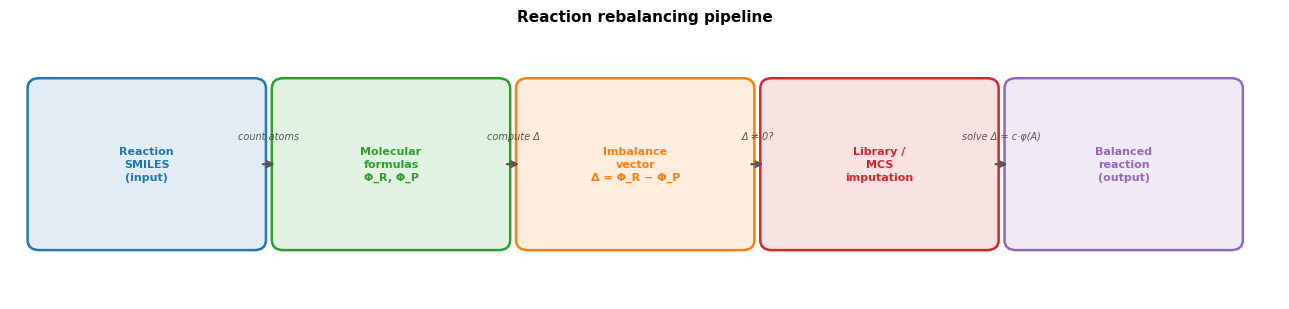

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3.2)
ax.axis("off")
ax.set_title("Reaction rebalancing pipeline", fontsize=11, fontweight="bold", pad=6)

_STEPS = [
    ("Reaction\nSMILES\n(input)", "#1F77B4"),
    ("Molecular\nformulas\nΦ_R, Φ_P", "#2CA02C"),
    ("Imbalance\nvector\nΔ = Φ_R − Φ_P", "#FF7F0E"),
    ("Library /\nMCS\nimputation", "#D62728"),
    ("Balanced\nreaction\n(output)", "#9467BD"),
]
_ARROW_LABELS = ["count atoms", "compute Δ", "Δ ≠ 0?", "solve Δ = c·φ(A)"]

xs = [0.3, 2.8, 5.3, 7.8, 10.3]
w, h = 2.2, 1.8

for x, (label, color) in zip(xs, _STEPS):
    bbox = FancyBboxPatch(
        (x, 0.7),
        w,
        h,
        boxstyle="round,pad=0.12",
        linewidth=1.8,
        edgecolor=color,
        facecolor=color + "22",
    )
    ax.add_patch(bbox)
    ax.text(
        x + w / 2,
        0.7 + h / 2,
        label,
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=color,
        linespacing=1.4,
    )

for i, lbl in enumerate(_ARROW_LABELS):
    x_start = xs[i] + w + 0.06
    x_end = xs[i + 1] - 0.06
    ymid = 0.7 + h / 2
    ax.annotate(
        "",
        xy=(x_end, ymid),
        xytext=(x_start, ymid),
        arrowprops=dict(arrowstyle="->", color="#555", lw=1.6),
    )
    ax.text(
        (x_start + x_end) / 2,
        ymid + 0.28,
        lbl,
        ha="center",
        va="bottom",
        fontsize=7,
        color="#555",
        style="italic",
    )

plt.tight_layout()
plt.show()

Now consider the following simple reaction. 
By comparing the total molecular formulas of the reactant and product sides,
we can immediately detect a **missing water molecule on the product side**.

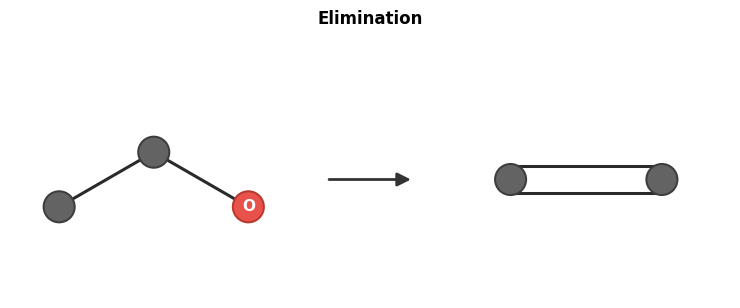

In [8]:
from synedu.Utils import draw_rxn_graph

fig = draw_rxn_graph(
    'CCO>>C=C',
    title="Elimination",
    highlight_changes=True,
    label_mode="hetero",
    show_indices=False,
    aromatic_style="circle",
    show_legend=False,
)

To automate this imputation, we introduce a small set of utility functions
for parsing reactions, computing formula imbalances, and resolving them
using predefined auxiliary species.

In [9]:
from __future__ import annotations

from collections import Counter
from typing import Tuple

from rdkit import Chem


# Reaction decomposition


def parse_reaction_smiles(rsmi: str) -> Tuple[list[Chem.Mol], list[Chem.Mol]]:
    """
    Parse a reaction SMILES into reactant and product molecule lists.

    Parameters
    ----------
    rsmi : str
        Reaction SMILES, e.g. "CCO.O>>CC=O"

    Returns
    -------
    reactants : list[Chem.Mol]
    products  : list[Chem.Mol]
    """
    try:
        lhs, rhs = rsmi.split(">>")
    except ValueError:
        raise ValueError("Reaction SMILES must contain '>>'")

    reactants = [Chem.MolFromSmiles(s) for s in lhs.split(".") if s]
    products = [Chem.MolFromSmiles(s) for s in rhs.split(".") if s]

    if any(m is None for m in reactants + products):
        raise ValueError("Invalid molecule in reaction SMILES")

    return reactants, products


# Formula representation


def molecular_formula(mol: Chem.Mol) -> Counter[str]:
    """
    Compute the molecular formula φ(M) as an element-count vector.

    Returns
    -------
    Counter[str]
        Mapping element symbol -> atom count
    """
    mol = Chem.AddHs(mol)

    formula = Counter()
    for atom in mol.GetAtoms():
        formula[atom.GetSymbol()] += 1
    return formula


def total_formula(mols: list[Chem.Mol]) -> Counter[str]:
    """
    Compute total formula Φ = sum φ(M) over a list of molecules.
    """
    total = Counter()
    for m in mols:
        total += molecular_formula(m)
    return total


# Imbalance detection

from collections import Counter
from typing import Literal, Tuple


def signed_difference(a: Counter[str], b: Counter[str]) -> Counter[str]:
    """
    Compute signed element-wise difference a - b
    without dropping negative values.
    """
    delta = Counter()
    for elem in set(a) | set(b):
        v = a.get(elem, 0) - b.get(elem, 0)
        if v != 0:
            delta[elem] = v
    return delta


def reaction_imbalance(
    rsmi: str,
) -> Tuple[
    Counter[str],
    Literal[
        "balanced",
        "missing_in_products",
        "missing_in_reactants",
        "missing_in_both_sides",
    ],
]:
    """
    Compute the reaction imbalance vector Δ = Φ_R − Φ_P
    and classify where material is missing.

    Returns
    -------
    delta : Counter[str]
        Element-wise imbalance (positive = excess on reactant side)
    status : str
        One of:
        - 'balanced'
        - 'missing_in_products'
        - 'missing_in_reactants'
        - 'missing_in_both_sides'
    """
    reactants, products = parse_reaction_smiles(rsmi)

    phi_R = total_formula(reactants)
    phi_P = total_formula(products)
    delta = signed_difference(phi_R, phi_P)

    if not delta:
        return delta, "balanced"

    has_pos = any(v > 0 for v in delta.values())
    has_neg = any(v < 0 for v in delta.values())

    if has_pos and not has_neg:
        status = "missing_in_products"
    elif has_neg and not has_pos:
        status = "missing_in_reactants"
    else:
        status = "missing_in_both_sides"

    return delta, status

**Stored in `synedu.Utils`** — reaction-balance helpers are now packaged for later curation and rule-extraction steps:
```python
from synedu.Utils.reaction import parse_reaction_smiles, reaction_imbalance
```
This keeps the formula-balance convention consistent across later tasks.

In [10]:
rsmi = 'CCO>>C=C'
delta, status = reaction_imbalance(rsmi)
print(delta, status)

Counter({'H': 2, 'O': 1}) missing_in_products


In [11]:
from collections import Counter
from typing import Dict, Optional

AUX_LIBRARY: Dict[str, Counter[str]] = {
    "O": Counter({"H": 2, "O": 1}),  # H2O
    "[H+]": Counter({"H": 1}),
    "[OH-]": Counter({"H": 1, "O": 1}),
}

**Q3 — Auxiliary imputation feasibility**

You are given an element-wise imbalance vector  
$$
\Delta \in \mathbb{Z}^{|\mathcal E|}
$$
and an auxiliary species $A$ with molecular formula  
$$
\phi(A) \in \mathbb{N}^{|\mathcal E|}.
$$

The goal is to decide whether the imbalance can be resolved by adding
$c$ copies of $A$, i.e.
$$
\Delta = c \cdot \phi(A), \qquad c \in \mathbb{N}.
$$

---

**Hint:**

Think element-wise.  
If such a $c$ exists, then for every element $e$,
the ratio $\Delta_e / \phi_e(A)$ must be:
1. an integer,
2. the same for all elements,
3. and strictly positive.

Also ensure that no extra elements remain unexplained.



---

<details class="synedu-solution">
<summary><strong>Solution</strong></summary>

```python
from collections import Counter
from typing import Optional


def can_impute_with_aux(
    delta: Counter[str],
    aux_formula: Counter[str],
) -> Optional[int]:
    """
    Check whether Δ can be written as c · φ(A).
    """
    if not delta:
        return 0

    ratios = []

    for elem, count in aux_formula.items():
        if elem not in delta:
            return None
        if delta[elem] % count != 0:
            return None
        ratios.append(delta[elem] // count)

    if not ratios or len(set(ratios)) != 1:
        return None

    c = ratios[0]
    if c <= 0:
        return None

    remainder = delta - Counter({k: c * v for k, v in aux_formula.items()})
    if remainder:
        return None

    return c
```

</details>


In [12]:
def impute_rsmi_rule(
    rsmi: str,
    delta: Counter[str],
    status: str,
    library: Dict[str, Counter[str]] = AUX_LIBRARY,
) -> Optional[str]:
    if status == "balanced":
        return rsmi

    if status == "missing_in_both_sides":
        return None

    lhs, rhs = rsmi.split(">>")
    # decide direction
    if status == "missing_in_products":
        target_delta = delta
        side = "products"
    elif status == "missing_in_reactants":
        target_delta = -delta
        side = "reactants"
    else:
        return None

    # try library
    for aux_smiles, formula in library.items():
        c = can_impute_with_aux(target_delta, formula)
        if c is None:
            continue

        aux_block = ".".join([aux_smiles] * c)

        if side == "products":
            rhs = rhs + "." + aux_block if rhs else aux_block
        else:
            lhs = lhs + "." + aux_block if lhs else aux_block

        return f"{lhs}>>{rhs}"

    return None


def can_impute_with_aux(
    delta: Counter[str],
    aux_formula: Counter[str],
) -> Optional[int]:
    """
    Check whether Δ can be written as c · φ(A).
    """
    if not delta:
        return 0

    ratios = []

    for elem, count in aux_formula.items():
        if elem not in delta:
            return None
        if delta[elem] % count != 0:
            return None
        ratios.append(delta[elem] // count)

    if not ratios or len(set(ratios)) != 1:
        return None

    c = ratios[0]
    if c <= 0:
        return None

    remainder = delta - Counter({k: c * v for k, v in aux_formula.items()})
    if remainder:
        return None

    return c

**Stored in `synedu.Utils`** — auxiliary-species imputation is available as a reusable utility:
```python
from synedu.Utils.reaction import AUX_LIBRARY, can_impute_with_aux, impute_rsmi_rule
```
Later notebooks can focus on when to impute, rather than redefining the same bookkeeping.

Now try with the above example

CCO>>C=C.O


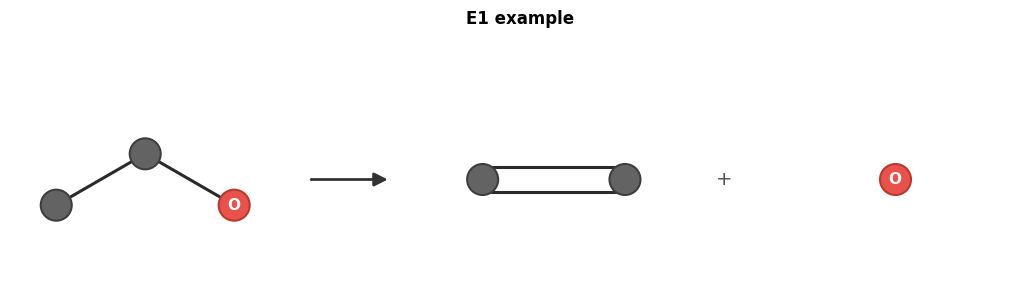

In [16]:
delta, status = reaction_imbalance(rsmi)
rsmi_balanced = impute_rsmi_rule(rsmi, delta, status, library=AUX_LIBRARY)

print(rsmi_balanced)
if rsmi_balanced:
    fig = draw_rxn_graph(
        rsmi_balanced,
        title="E1 example",
        highlight_changes=True,
        label_mode="hetero",
        show_indices=False,
        aromatic_style="circle",
        show_legend=False,
    )

### Before / after rebalancing

Imbalanced reactions are missing one or more species. The gallery below shows each reaction before and after library-based imputation — atoms and bonds are unchanged; only the missing auxiliary species (water, HCl) are appended to the correct side.

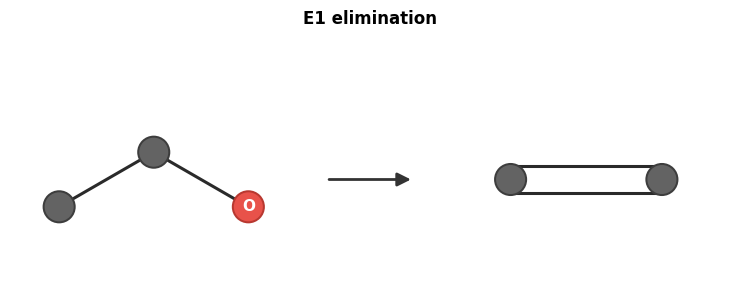

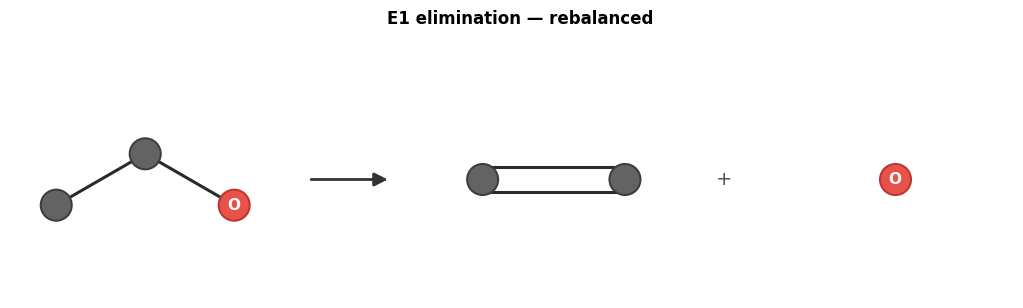

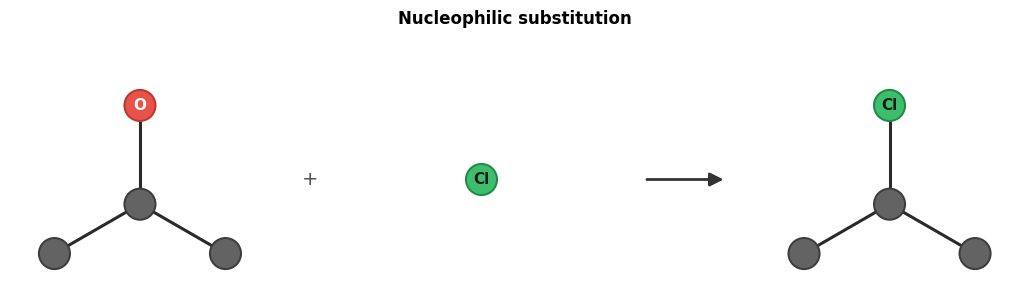

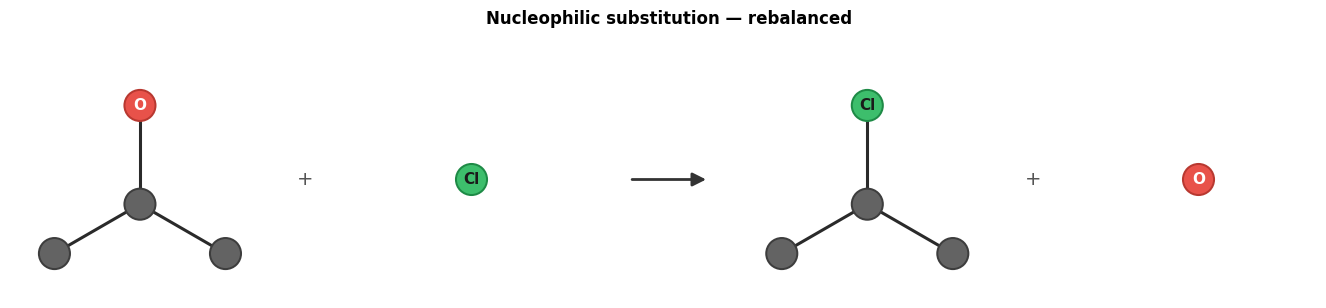

In [22]:
from collections import Counter
from synedu.Utils.rxn_vis import draw_rxn_graph
import matplotlib.pyplot as plt

_AUX_EXT = {
    "O": Counter({"H": 2, "O": 1}),
    "[H+]": Counter({"H": 1}),
    "[OH-]": Counter({"H": 1, "O": 1}),
    "Cl": Counter({"H": 1, "Cl": 1}),
}

_EXAMPLES = [
    ("CCO>>C=C", "E1 elimination"),
    ("CC(C)O.Cl>>CC(C)Cl", "Nucleophilic substitution"),
]

for rsmi_ex, title in _EXAMPLES:
    delta_ex, status_ex = reaction_imbalance(rsmi_ex)
    rsmi_bal_ex = (
        impute_rsmi_rule(rsmi_ex, delta_ex, status_ex, library=_AUX_EXT) or rsmi_ex
    )

    print(f"\n{title}")
    print("Before (imbalanced):")
    draw_rxn_graph(rsmi_ex, title=title, highlight_changes=False, show_legend=False)
    plt.show()

    print("After (rebalanced):")
    draw_rxn_graph(
        rsmi_bal_ex,
        title=f"{title} — rebalanced",
        highlight_changes=False,
        show_legend=False,
    )
    plt.show()

    print("-" * 48)

**Q4 — Rebalance some reactions**

Extend the auxiliary-species library and use it to rebalance these reactions:

```text
CC(C)O>>CC(C)Cl.O
CC(C)Cl>>CC(C)N.Cl
CC(=O)O>>CC(=O)OC.O
```

<details class="synedu-solution">
<summary><strong>Solution idea</strong></summary>

add common auxiliary species such as water, hydrochloric acid, ammonia, hydroxide, and methanol to the library. For each reaction, compute the imbalance with `reaction_imbalance`, call `impute_rsmi`, and keep the balanced reaction when imputation succeeds.

</details>


## 3. MCS-based reaction rebalancing

For **non-carbon compounds**, missing species can often be imputed from a
finite library. In contrast, for **carbon-containing compounds**, the space of
possible structures grows exponentially, making library-based enumeration
impractical at scale.

Instead, we use **reaction alignment** to identify missing **structural motifs**
via MCS and apply **rule-based reasoning** to complete and rebalance reactions.

In this section, we directly use functionality from **SynKit** [\[6\]](#6.-References)
(`pip install synkit`) and explore an established tool for reaction rebalancing,
**SynRBL** [\[7\]](#6.-References) (`pip install synrbl`).

The focus is on applying **MCS-based alignment** to detect missing species,
infer stoichiometry, and rebalance reactions in a chemically consistent manner.

(Counter({'C': 8, 'H': 6, 'O': 2}), 'missing_in_products')


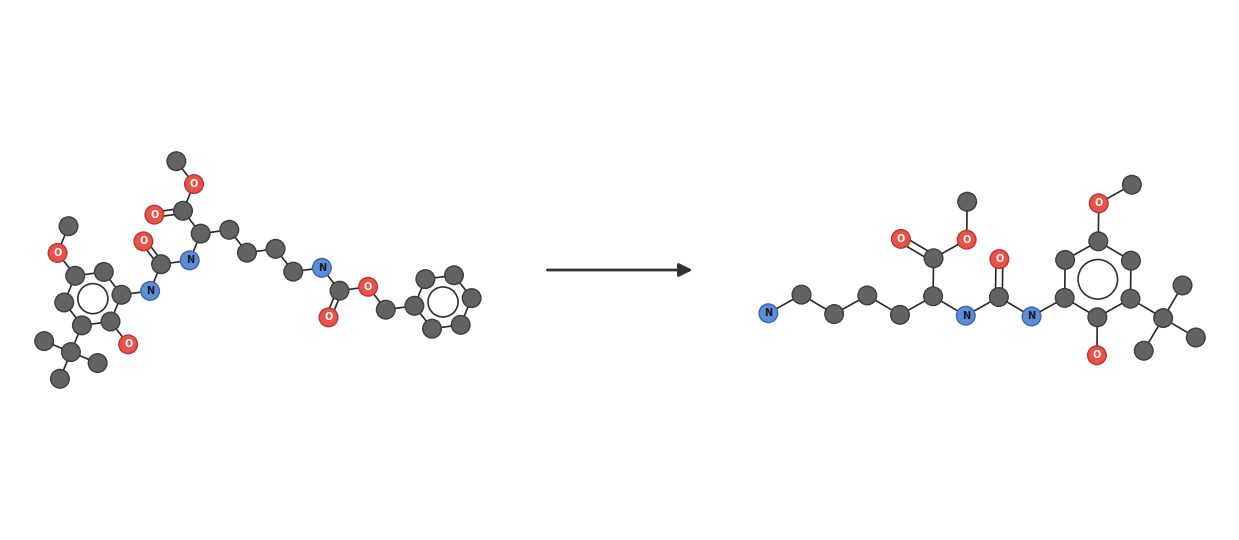

In [ ]:
rsmi = (
    "COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
    ">>"
    "COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
)


print(reaction_imbalance(rsmi))

fig = draw_rxn_graph(
    rsmi,
)

The missing compound has the formula **C₈H₆O₂**, which corresponds to many possible structures, making full library enumeration infeasible.  
Instead, by extracting the **maximum common subgraph** between reactants and products, the remaining unmatched portion directly reveals the **missing fragment**.

In [24]:
from synedu.Utils.reaction import (
    rsmi_to_graph,
)  # ► stored in synedu.Utils.reaction.rsmi_to_graph
from synkit.Graph.Matcher.mcs_matcher import MCSMatcher  # fast MCS for molecular graph

r, p = rsmi_to_graph(rsmi, drop_non_aam=False, use_index_as_atom_map=False)

mcs = MCSMatcher(
    node_attrs=['element', 'charge', 'aromatic'],
    edge_attrs=['order'],
    prune_automorphisms=True,  # reduce the redundant maps
)
mcs.find_common_subgraph(r, p, mcs=True)
maps = mcs.get_mappings()
maps

[{1: 1,
  2: 2,
  3: 3,
  4: 4,
  5: 5,
  6: 6,
  7: 7,
  8: 8,
  9: 9,
  10: 10,
  11: 21,
  12: 22,
  13: 23,
  14: 24,
  15: 25,
  16: 26,
  17: 27,
  18: 28,
  19: 29,
  20: 30,
  21: 31,
  22: 32,
  23: 33,
  24: 34,
  25: 35,
  26: 36,
  27: 37}]

This mapping corresponds to a `pattern_to_host` alignment, i.e. from a
smaller molecule to a larger one.  
In this example, the mapping is from the **product** (pattern) to the
**reactant** (host).

The unmatched region in the host graph therefore identifies the
**missing subgraph**, which must be imputed to complete and rebalance
the reaction.

In [25]:
exist_indice = [value for _, value in maps[0].items()]
missing_indice = [value for value in r.nodes if value not in exist_indice]

In [26]:
import networkx as nx
from typing import Iterable


def extract_induced_subgraph(
    G: nx.Graph, nodes: Iterable[int], *, copy: bool = True
) -> nx.Graph:
    nodes = set(nodes)

    # Safety check
    missing = nodes - set(G.nodes)
    if missing:
        raise KeyError(f"Nodes not found in graph: {sorted(missing)}")

    H = G.subgraph(nodes)
    return H.copy() if copy else H

**Stored in `synedu.Utils`** — induced-subgraph extraction is available for later rule-context construction:
```python
from synedu.Utils.graph import extract_induced_subgraph
```

<Axes: >

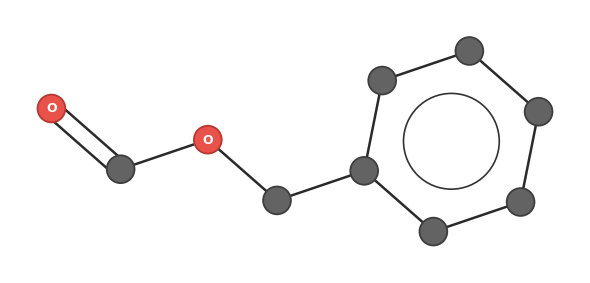

In [27]:
sub = extract_induced_subgraph(r, missing_indice)
draw_molecular_graph(sub)

**Q5 — Detect valence violations in a molecular subgraph**

Given a **molecular graph** represented as a **NetworkX graph**, detect atoms
whose **total valence violates basic chemical constraints**, using only
**local graph information** (node and edge attributes).

This exercise emphasizes a **purely graph-theoretic definition of valence**,
independent of RDKit sanitization, atom typing, or implicit chemistry rules.

---

**Step-by-step tasks**

1. **Define allowed valences**  
   Specify an extensible mapping
   $$
   \mathcal{V} : \text{Element} \;\to\; \{\text{allowed valences}\}
   $$
   for common elements (C, N, O, S, P).

2. **Compute total valence per atom**  
   For each atom $i$, compute the total valence
   $$
   v_i
   \;=\;
   h_i
   \;+\;
   \sum_{(i,j)\in E} b_{ij},
   $$
   where $h_i$ is the hydrogen count and $b_{ij}$ is the bond order of the
   bond between atoms $i$ and $j$.

3. **Check against valence constraints**  
   Verify whether
   $$
   v_i \in \mathcal{V}\bigl(a(i)\bigr),
   $$
   where $a(i)$ denotes the element type of atom $i$.

4. **Collect violations**  
   Record all atoms $i$ for which
   $$
   v_i \notin \mathcal{V}\bigl(a(i)\bigr).
   $$

5. **Report diagnostics**  
   For each violating atom, report:
   $$
   (\text{atom index},\; \text{element},\; v_i,\; \mathcal{V}(a(i))).
   $$

---

<details class="synedu-solution">
<summary><strong>Solution</strong></summary>

```python
_ALLOWED_VALENCE = {
    "C": {4},
    "N": {3, 4},  
    "O": {2},
    "S": {2, 4, 6},
    "P": {3, 5},
}

import networkx as nx
from typing import Dict


def find_valence_violations(G: nx.Graph) -> Dict[int, Dict]:
    violations = {}

    for node, data in G.nodes(data=True):
        element = data.get("element")
        hcount = data.get("hcount", 0)

        if element not in _ALLOWED_VALENCE:
            continue  # skip unknown elements

        bond_valence = 0.0
        for nbr in G.neighbors(node):
            bond_valence += G.edges[node, nbr].get("order", 1.0)

        total_valence = hcount + bond_valence
        allowed = _ALLOWED_VALENCE[element]

        if total_valence not in allowed:
            violations[node] = {
                "element": element,
                "hcount": hcount,
                "bond_valence": bond_valence,
                "total_valence": total_valence,
                "allowed": sorted(allowed),
            }

    return violations


violations = find_valence_violations(sub)

for idx, info in violations.items():
    print(
        f"Atom {idx} ({info['element']}): "
        f"total={info['total_valence']} "
        f"(h={info['hcount']} + bonds={info['bond_valence']}), "
        f"allowed={info['allowed']}"
    )
```

</details>


Then we need to mark this atom need to be merged with some subgraphs. We introduce wildcard here

In [28]:
import networkx as nx
from typing import List


_ALLOWED_VALENCE = {
    "C": {4},
    "N": {3, 4},  # neutral amine (3), ammonium (4)
    "O": {2},
    "S": {2, 4, 6},
    "P": {3, 5},
}


def add_wildcard(
    G: nx.Graph,
    indices: List[int],
) -> nx.Graph:
    """
    Return a copy of the graph with wildcard (*) atoms added
    to balance valence for selected atoms.

    For each atom index in `indices`, compute:
        total_valence = hcount + sum(bond orders)

    If total_valence is smaller than the maximum allowed valence
    for that element, add a wildcard atom (*) connected by a bond
    whose order exactly compensates the deficit.

    Parameters
    ----------
    G : nx.Graph
        Molecular graph (original graph is NOT modified).
    indices : List[int]
        Atom indices to check and repair.

    Returns
    -------
    nx.Graph
        New graph with wildcard atoms added.
    """
    H = G.copy()

    next_idx = max(H.nodes, default=0) + 1

    for atom in indices:
        if atom not in H:
            continue

        data = H.nodes[atom]
        element = data.get("element")
        hcount = data.get("hcount", 0)

        if element not in _ALLOWED_VALENCE:
            continue

        bond_valence = sum(
            H.edges[atom, nbr].get("order", 1.0) for nbr in H.neighbors(atom)
        )

        total_valence = hcount + bond_valence
        allowed = max(_ALLOWED_VALENCE[element])

        deficit = allowed - total_valence
        if deficit <= 0:
            continue

        wc = next_idx
        next_idx += 1

        H.add_node(
            wc,
            element="*",
            aromatic=False,
            hcount=0,
            charge=0,
            wildcard=True,
        )
        H.add_edge(atom, wc, order=deficit)

    return H

**Stored in `synedu.Utils`** — wildcard repair and graph gluing helpers are packaged for later MCS-based completion tasks:
```python
from synedu.Utils.graph import add_wildcard, find_wildcards, merge_graphs_on_wildcard
from synedu.Utils.reaction import impute_smi_mcs
```

In [29]:
from synedu.Utils.graph import (
    print_graph_attributes,
)  # ► stored in synedu.Utils.graph.print_graph_attributes

wc_sub = add_wildcard(sub, indices=list(sub.nodes()))

print_graph_attributes(wc_sub)

Graph: 11 nodes, 11 edges
Nodes:
  11: element='C', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=10
  12: element='O', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=11
  13: element='O', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=12
  14: element='C', formal_charge=0, aromatic=False, hcount=2, atom_map=0, rdkit_idx=13
  15: element='C', formal_charge=0, aromatic=True, hcount=0, atom_map=0, rdkit_idx=14
  16: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=0, rdkit_idx=15
  17: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=0, rdkit_idx=16
  18: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=0, rdkit_idx=17
  19: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=0, rdkit_idx=18
  20: element='C', formal_charge=0, aromatic=True, hcount=1, atom_map=0, rdkit_idx=19
  21: element='*', aromatic=False, hcount=0, charge=0, wildcard=True
Edges:
  (11, 12): order=2.0, arom

In [30]:
# Now we need a subgraph to merge, we try with hydroxy group
from synedu.Utils.conversion import (
    smiles_to_graph,
)  # ► stored in synedu.Utils.conversion.smiles_to_graph

smiles = '*[O][H]'
add_sub = smiles_to_graph(smiles)
print_graph_attributes(add_sub)

Graph: 3 nodes, 2 edges
Nodes:
  1: element='*', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=0
  2: element='O', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=1
  3: element='H', formal_charge=0, aromatic=False, hcount=0, atom_map=0, rdkit_idx=2
Edges:
  (1, 2): order=1.0, aromatic=False
  (2, 3): order=1.0, aromatic=False


**Stored in synedu.Utils** — The I/O helpers used in this section (`smiles_to_graph`, `graph_to_smi`, `rsmi_to_graph`, `graph_to_rsmi`) are now packaged in `synedu.Utils`:
```python
from synedu.Utils.conversion import smiles_to_graph, graph_to_smi
from synedu.Utils.reaction  import rsmi_to_graph, graph_to_rsmi
```
Later notebooks import from these modules directly instead of relying on SynKit.

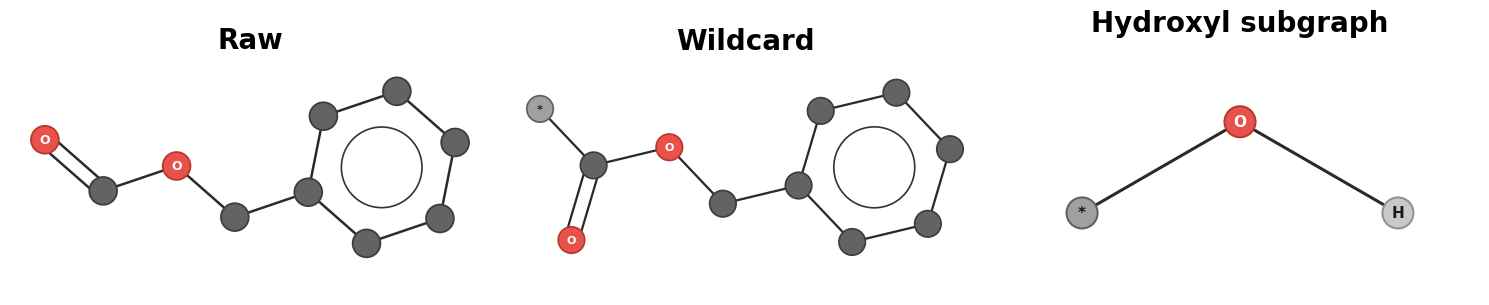

In [31]:
import matplotlib.pyplot as plt

new_sub = add_wildcard(sub, indices=list(sub.nodes()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
draw_molecular_graph(
    sub,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[0].set_title("Raw", fontsize=20, weight='bold')

draw_molecular_graph(
    wc_sub,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[1].set_title("Wildcard", fontsize=20, weight='bold')

draw_molecular_graph(
    add_sub,
    ax=axes[2],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[2].set_title("Hydroxyl subgraph", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

We now merge the wildcard subgraph with the hydroxyl subgraph,
using the wildcard nodes as anchors for attachment.

In [32]:
import networkx as nx


def find_wildcards(G: nx.Graph) -> list[int]:
    """Return indices of wildcard (*) nodes."""
    return [n for n, d in G.nodes(data=True) if d.get("element") == "*"]


def _get_unique_wildcard(G: nx.Graph, label: str) -> int:
    wcs = find_wildcards(G)
    if len(wcs) != 1:
        raise ValueError(f"{label} must contain exactly one wildcard")
    return wcs[0]


def merge_graphs_on_wildcard(
    G1: nx.Graph,
    G2: nx.Graph,
    *,
    wc1: int | None = None,
    wc2: int | None = None,
) -> nx.Graph:
    """
    Merge two molecular graphs by gluing them at wildcard (*) nodes.

    The wildcard nodes are removed, and their unique neighbors are connected.
    """
    # --- identify wildcards ---
    wc1 = wc1 if wc1 is not None else _get_unique_wildcard(G1, "G1")
    wc2 = wc2 if wc2 is not None else _get_unique_wildcard(G2, "G2")

    # --- check 1–1 attachment ---
    nbrs1 = list(G1.neighbors(wc1))
    nbrs2 = list(G2.neighbors(wc2))
    if len(nbrs1) != 1 or len(nbrs2) != 1:
        raise ValueError("Only 1–1 wildcard gluing is supported")

    u1 = nbrs1[0]
    u2 = nbrs2[0]

    # --- initialize merged graph ---
    G = nx.Graph()

    # copy G1 without wildcard
    for n, d in G1.nodes(data=True):
        if n != wc1:
            G.add_node(n, **d)
    for u, v, d in G1.edges(data=True):
        if wc1 not in (u, v):
            G.add_edge(u, v, **d)

    # copy G2 without wildcard (with offset)
    offset = max(G.nodes, default=-1) + 1
    node_map = {}

    for n, d in G2.nodes(data=True):
        if n == wc2:
            continue
        node_map[n] = n + offset
        G.add_node(node_map[n], **d)

    for u, v, d in G2.edges(data=True):
        if wc2 not in (u, v):
            G.add_edge(node_map[u], node_map[v], **d)

    # --- glue the attachment points ---
    bond_order = min(
        G1.edges[wc1, u1]["order"],
        G2.edges[wc2, u2]["order"],
    )
    G.add_edge(u1, node_map[u2], order=bond_order)

    return G

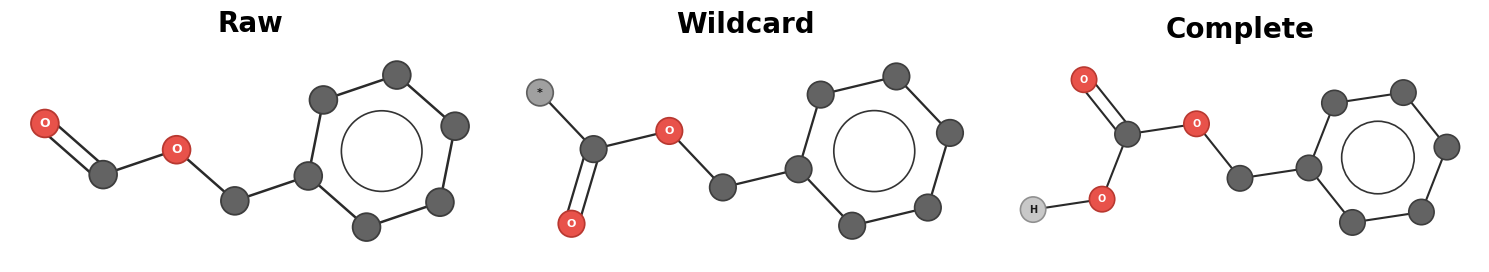

In [33]:
missing_graph = merge_graphs_on_wildcard(wc_sub, add_sub)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
draw_molecular_graph(
    sub,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[0].set_title("Raw", fontsize=20, weight='bold')

draw_molecular_graph(
    new_sub,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[1].set_title("Wildcard", fontsize=20, weight='bold')

draw_molecular_graph(
    missing_graph,
    ax=axes[2],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[2].set_title("Complete", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

In [34]:
from synedu.Utils.conversion import (
    graph_to_smi,
)  # ► stored in synedu.Utils.conversion.graph_to_smi

missing_smi = graph_to_smi(missing_graph)
print(missing_smi)

[H]OC(=O)OCc1ccccc1


**Q6 — Reaction completion via MCS-based imputation**

You are given a reaction SMILES `rsmi` with a detected imbalance and a
missing species identified via MCS (`missing_smi`).

---

**Tasks**

1. **Impute missing structure**  
   Use `impute_smi_mcs` to add `missing_smi` to the appropriate side
   of the reaction.

2. **Re-check balance**  
   Recompute the imbalance using `reaction_imbalance`.

3. **Decide outcome**  
   - Balanced → accept reaction  
   - Unbalanced → apply further imputation


---

<details class="synedu-solution">
<summary><strong>Solution</strong></summary>

```python
def impute_smi_mcs(
    rsmi: str,
    status: str,
    missing_smi: str | None = None,
) -> str | None:

    # --- trivial cases ---
    if status == "balanced" or missing_smi is None:
        return rsmi

    if status == "missing_in_both_sides":
        return None

    # --- split reaction ---
    lhs, rhs = rsmi.split(">>")

    # --- impute on the correct side ---
    if status == "missing_in_products":
        rhs = f"{rhs}.{missing_smi}" if rhs else missing_smi
    elif status == "missing_in_reactants":
        lhs = f"{lhs}.{missing_smi}" if lhs else missing_smi
    else:
        return None

    return f"{lhs}>>{rhs}"



# impute missing SMILES
mcs_rsmi  = impute_smi_mcs(rsmi, status, missing_smi=missing_smi)

# re-checking
delta, status = reaction_imbalance(mcs_rsmi)
print(delta, status)

# rule-based imputation
rsmi_balanced = impute_rsmi_rule(mcs_rsmi, delta, status, library=AUX_LIBRARY)
print(rsmi_balanced)
```

</details>


Here we demonstrate the same rebalancing task using **SynRBL** [\[6\]](#6.-References), a dedicated
rule-based reaction rebalancer. Starting from an imbalanced reaction SMILES,
SynRBL automatically detects the missing fragment via MCS-based alignment and
completes the reaction by imputing the appropriate substructure. The output
indicates that the reaction is successfully solved, reports the applied rules,
and assigns a high confidence score, illustrating how MCS-based reasoning can
robustly recover missing species without manual intervention.

In [35]:
# pip install synrbl
from synrbl import Balancer

smiles = (
    "COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O>>"
    + "COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
)
synrbl = Balancer()

results = synrbl.rebalance(smiles, output_dict=True)
results

[{'reaction': 'COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O>>COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O=C(O)OCc1ccccc1',
  'solved': True,
  'input_reaction': 'COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O>>COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O',
  'issue': '',
  'rules': ['append O when next to O or N', 'default single bond'],
  'solved_by': 'mcs-based',
  'confidence': 0.9990000128746033}]

## 4. Discussion

- **MCS** is a useful alignment primitive but is heuristic and may yield
  non-unique solutions.
- Many reactions in databases are **incomplete**, most often missing water
  or other small molecules.
- Library-based imputation is feasible for **non-carbon species** but becomes
  intractable for carbon-containing compounds.
- **MCS-based methods** help localize missing carbon fragments but still require
  chemical rules and domain knowledge for valid completion.
- **SynRBL** combines MCS alignment with rule-based reasoning to perform
  practical reaction rebalancing.

<a id="5-quiz"></a>

## 5. Quiz

1. Why is MCS useful for molecular alignment, and why can MCS be non-unique or heuristic in practical chemistry toolkits?
2. Which missing species are easiest to impute in incomplete reaction records, and what chemical information makes them easier?
3. Why does library-based imputation scale poorly for carbon-containing missing fragments?
4. What information can MCS provide when rebalancing reactions with missing carbon fragments, and where can it still fail?


## 6. References

1. RDKit documentation. https://www.rdkit.org/docs/
2. RDKit MCS (`rdFMCS`) documentation. https://www.rdkit.org/docs/source/rdkit.Chem.rdFMCS.html
3. Phan, T.-L. *et al.* Reaction rebalancing: a novel approach to curating reaction databases. *Journal of Cheminformatics* **16**, 82 (2024). https://doi.org/10.1186/s13321-024-00875-4
4. Raymond, J. W.; Willett, P. Maximum common subgraph isomorphism algorithms for the matching of chemical structures. *Journal of Computer-Aided Molecular Design* **16**, 521-533 (2002). https://doi.org/10.1023/A:1021271615909
5. NetworkX documentation. https://networkx.org/documentation/stable/
6. Bonchev, D.; Rouvray, D. H., eds. *Chemical Graph Theory: Introduction and Fundamentals*. Abacus Press (1991).
7. Diestel, R. *Graph Theory*, 5th ed. Springer (2017). https://doi.org/10.1007/978-3-662-53622-3
8. Phan, T.-L. *et al.* SynKit: A graph-based framework for rule-based reaction modeling. *Journal of Chemical Information and Modeling* (2025). https://doi.org/10.1021/acs.jcim.5c02123
